<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/Trying_FewShot_ZeroShot_MetaLearning_ADSB_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADS-B Message Injection Attacks — Few-Shot, Zero-Shot & Meta-Learning for Intrusion Detection

**Dataset:** [ADS-B Message Injection Attacks Dataset](https://data.mendeley.com/datasets/6fhw732ccz) (Ould Slimane, Benouadah & Kaabouch, 2022)

This dataset contains 22,316 ADS-B state-vector messages collected from the OpenSky Network, with legitimate
traffic labeled `0` and three injected-message attack types simulated on top of real flights:

| Label | Attack type | Description |
|---|---|---|
| 0 | Legitimate | Authentic ADS-B messages, no attack |
| 1 | Path modification | Gradual manipulation of an aircraft's reported trajectory (lat/lon) |
| 2 | Ghost aircraft injection | A fabricated aircraft track injected into the airspace |
| 3 | Velocity drift | Gradual manipulation of an aircraft's reported speed |

This notebook is built to run top-to-bottom in **Google Colab**. It covers:

1. Exploratory Data Analysis (EDA) — including two important **data-leakage findings** you should know about before you train anything
2. Preprocessing (with a leakage-aware train/test split)
3. **Meta-learning** (Prototypical Networks, trained episodically)
4. **Few-shot learning** for a held-out, never-trained-on attack class
5. **Zero-shot learning** for the same held-out class, using *zero* labeled examples
6. A discussion of how the three connect, plus concrete gaps you can turn into your thesis contribution


## 0. Setup
Upload `Dataset.csv` when prompted (or mount Drive and edit the path).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("torch    :", torch.__version__)
print("numpy    :", np.__version__)
print("pandas   :", pd.__version__)
print("sklearn  :", sklearn.__version__)
print("seaborn  :", sns.__version__)

torch    : 2.11.0+cpu
numpy    : 2.1.3
pandas   : 2.2.3
sklearn  : 1.6.1
seaborn  : 0.13.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = '/content/drive/MyDrive/Machine learning/ADSB.csv'
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(22316, 18)


,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,rss,doppler,label
0,1627918130,0c20b6,41.073349,-73.930298,194.919295,231.859760,0.0,CMP312,False,False,1364.0,10363.2,10675.62,1627918130,1627918130,-85.607674,588.045536,0
1,1627918140,0c20b6,41.062500,-73.948425,194.833737,231.647341,0.0,CMP312,False,False,1364.0,10363.2,10675.62,1627918140,1627918140,-85.601463,827.517243,0
2,1627918150,0c20b6,41.051393,-73.966952,195.153367,231.528897,0.0,CMP312,False,False,1364.0,10363.2,10675.62,1627918150,1627918150,-85.609035,774.034419,0
3,1627918160,0c20b6,41.040918,-73.984368,195.153367,231.528897,0.0,CMP312,False,False,1364.0,10363.2,10675.62,1627918160,1627918160,-85.631899,790.374778,0
4,1627918170,0c20b6,41.035418,-74.006463,195.237429,251.741020,0.0,CMP312,False,False,1364.0,10363.2,10675.62,1627918169,1627918170,-85.744771,-94.629770,1


## 1. Exploratory Data Analysis (EDA)



In [4]:
# print(df.dtypes)
# print("\nRows:", df.shape[0], " Columns:", df.shape[1])
print("\nUnique aircraft (icao24):", df['icao24'].nunique()) #TOTAL ase 275 ta
# print("Unique callsigns:", df['callsign'].nunique())
df.describe(include='all').T



Unique aircraft (icao24): 275


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
time,22316.0,NaN,NaN,NaN,1627917737.833393,767.623426,1627916410.0,1627917080.0,1627917730.0,1627918390.0,1627919100.0
icao24,22316,275,a03f24,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,21175.0,NaN,NaN,NaN,40.744705,0.19235,40.194831,40.632862,40.730654,40.859344,41.411196
lon,21175.0,NaN,NaN,NaN,-73.715271,0.318908,-74.604835,-73.966371,-73.709679,-73.429947,-73.013855
velocity,19098.0,NaN,NaN,NaN,116.274996,77.304061,0.0,56.843152,95.725989,168.391324,311.837095
heading,19098.0,NaN,NaN,NaN,183.395058,110.63831,0.0,71.81344,201.133151,280.629755,359.999982
vertrate,19098.0,NaN,NaN,NaN,1.697861,11.411867,-28.28544,-3.57632,0.0,5.404464,36.993437
callsign,22128,277,DAL419,270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onground,22316,2,False,16979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spi,22316,2,False,22315,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_4331/533274066.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[label_names[i] for i in counts.index], y=counts.values, ax=ax, palette='viridis')


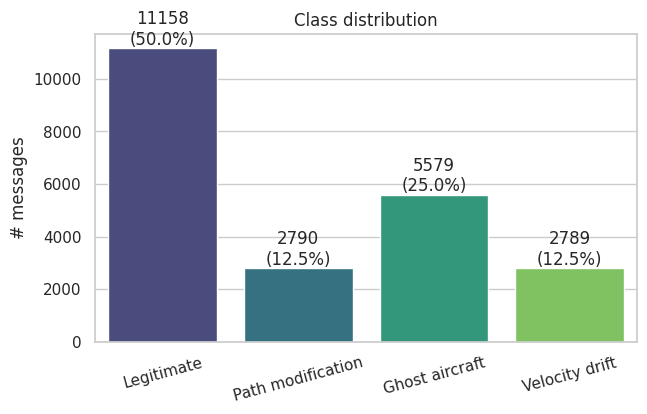

In [5]:
label_names = {0: 'Legitimate', 1: 'Path modification', 2: 'Ghost aircraft', 3: 'Velocity drift'}
counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots()
sns.barplot(x=[label_names[i] for i in counts.index], y=counts.values, ax=ax, palette='viridis')
ax.set_ylabel('# messages'); ax.set_title('Class distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 150, f"{v}\n({v/len(df)*100:.1f}%)", ha='center')
plt.xticks(rotation=15)
plt.show()

/tmp/ipykernel_4331/984458949.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='rocket')
/tmp/ipykernel_4331/984458949.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_ylabel('Feature'); ax.set_yticklabels(missing.index, rotation=0)


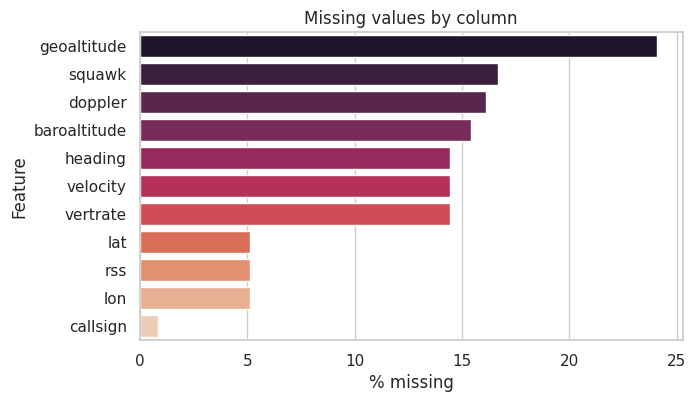

In [6]:
# --- Missing values overview ---
"""
This cell computes and visualizes the percentage of missing values per feature, filtering out any feature that has no missingness, so you can see at a glance which columns need imputation and how severe their gaps are.
"""
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

fig, ax = plt.subplots()
sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='rocket')
ax.set_xlabel('% missing'); ax.set_title('Missing values by column')
ax.set_ylabel('Feature'); ax.set_yticklabels(missing.index, rotation=0)
plt.show()

/tmp/ipykernel_4331/433251178.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_label = df.groupby('label').apply(lambda g: g.isnull().mean()).T


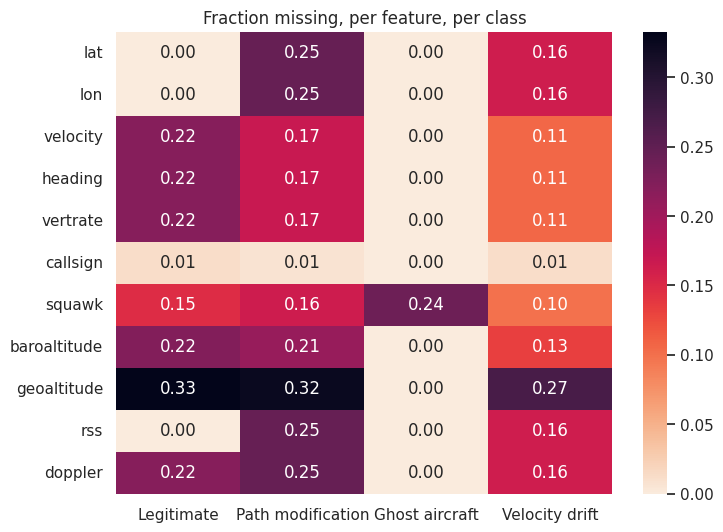

In [7]:
# --- IMPORTANT: missingness broken down BY CLASS ---

missing_by_label = df.groupby('label').apply(lambda g: g.isnull().mean()).T
missing_by_label.columns = [label_names[c] for c in missing_by_label.columns]
missing_by_label = missing_by_label.loc[(missing_by_label.sum(axis=1) > 0)]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(missing_by_label, annot=True, fmt='.2f', cmap='rocket_r', ax=ax)
ax.set_title('Fraction missing, per feature, per class')
plt.show()


Finding 1 -> for **every** feature, class `2` (ghost aircraft) has essentially
**0% missing values**, while classes `0`, `1` and `3` have 10–33% missingness on the same

In [8]:
# --- Does icao24 (aircraft identity) leak the label? ---
"""
1-> 179 means
179 aircrats appear with only one label accross all the rows.
mane 179 ta plane appear kore sudhumatro 1 ta label -> now this label can be 0, 1, 2, or 3
"""
leak_check = df.groupby('icao24')['label'].nunique().value_counts()
print("Number of DISTINCT labels seen per aircraft (icao24):")
print(leak_check)
print("\n->", (leak_check.index == 1).sum() and leak_check.loc[1] if 1 in leak_check.index else 0,
      "out of", df['icao24'].nunique(), "aircraft only ever appear under a single label.")


Number of DISTINCT labels seen per aircraft (icao24):
label
1    179
3     60
2     36
Name: count, dtype: int64

-> 179 out of 275 aircraft only ever appear under a single label.


Finding 2 —> Attack labels are tied to specific aircraft (icao24)


 Almost every `icao24` value maps to exactly **one** label. This makes sense given how the dataset was built (attacks were injected onto specific flights), but it means a **row-level random train/test split will leak the aircraft's identity across the split** — the model can partly memorize *which aircraft* is associated with *which attack*, rather than learning the general shape of the attack. We fix this below with a **group-aware split** (grouped by `icao24`), and we **exclude `icao24`/`callsign` as model features**.


/tmp/ipykernel_4331/651828810.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feat, ax=ax, palette='viridis')
/tmp/ipykernel_4331/651828810.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_names[i] for i in sorted(df['label'].unique())], rotation=20)
/tmp/ipykernel_4331/651828810.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=feat, ax=ax, palette='viridis')
/tmp/ipykernel_4331/651828810.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax

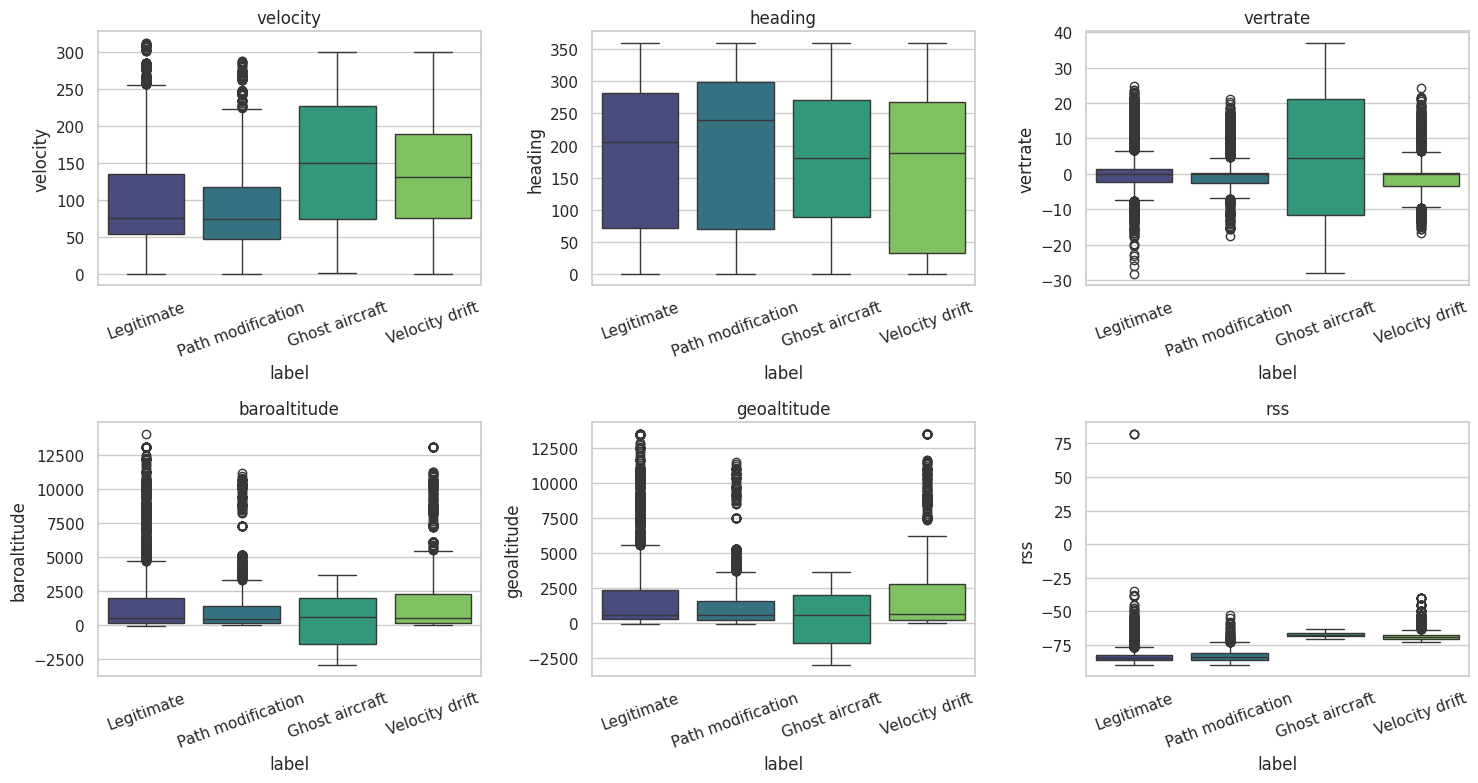

In [9]:
# --- Feature distributions per class (numeric features) ---
"""
in the total aircraft 276
179 aircraft appear with label 1, taile eita majority.
so this can create a problem, and the model starts memorizing the labels instead of generalizing and this is called IDENTITY LEAKAGE
"""


"""
we know the labels are leaky via identity; now let's look at whether the features themselves are informative with num_feats
"""
num_feats = ['velocity', 'heading', 'vertrate', 'baroaltitude', 'geoaltitude', 'rss']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), num_feats):
    sns.boxplot(data=df, x='label', y=feat, ax=ax, palette='viridis')
    ax.set_xticklabels([label_names[i] for i in sorted(df['label'].unique())], rotation=20)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


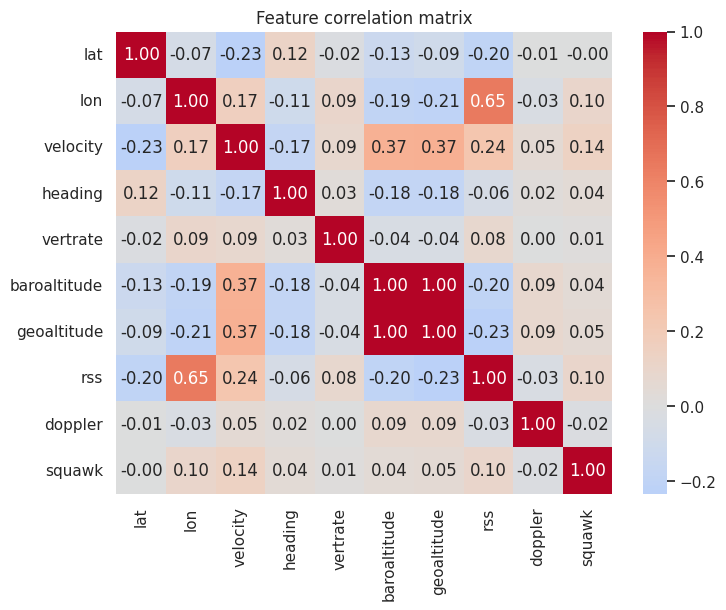

In [10]:
# --- Correlation heatmap (numeric features) ---
"""
well i havent dropped baroaltitude or geoaltitude.
These two in the correlation map shares exactly 1.00
I dont know if i should remove one now, im confused.


"""
corr_feats = ['lat','lon','velocity','heading','vertrate','baroaltitude','geoaltitude','rss','doppler','squawk']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[corr_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature correlation matrix')
plt.show()


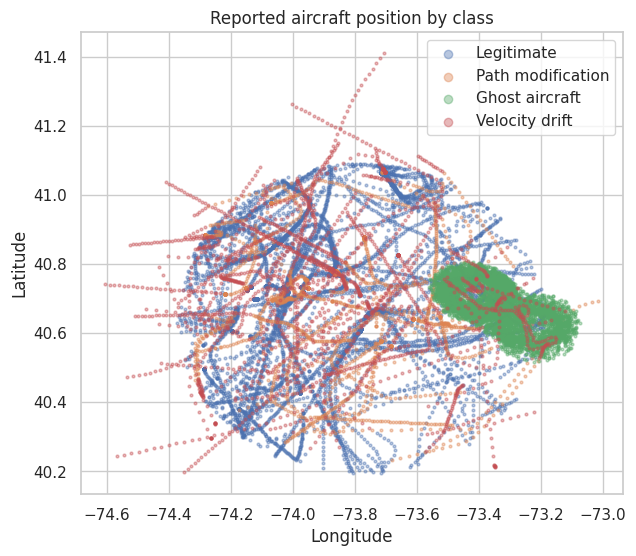

In [11]:
# --- Geospatial view: where do attacks show up? ---
fig, ax = plt.subplots(figsize=(7,6))
for lbl, color in zip([0,1,2,3], ['#4c72b0','#dd8452','#55a868','#c44e52']):
    sub = df[df['label']==lbl]
    ax.scatter(sub['lon'], sub['lat'], s=4, alpha=0.4, label=label_names[lbl], color=color)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.legend(markerscale=3)
ax.set_title('Reported aircraft position by class')
plt.show()


## 2. Preprocessing


Drop identifier / non-generalizable columns (`icao24`, `callsign` as features; raw epoch
   timestamps `time`, `lastposupdate`, `lastcontact`).

and then , Cast booleans (`onground`, `spi`) to integers.

Median-impute missing numeric values per column.

Standardize features (fit on train only).

Split with `GroupShuffleSplit` on `icao24` so no aircraft appears in both train and test. This split here is new for me with groupshufflesplit



In [12]:
FEATURE_COLS = ['lat','lon','velocity','heading','vertrate','onground','spi',
                'squawk','baroaltitude','geoaltitude','rss','doppler']

data = df.copy()
data['onground'] = data['onground'].astype(int)
data['spi'] = data['spi'].astype(int)

X = data[FEATURE_COLS].copy()
for c in X.columns:
    X[c] = X[c].fillna(X[c].median())

y = data['label'].values
groups = data['icao24'].values   # used ONLY for grouping the split, never as a model feature, karon we dropped icao24,

print("Any NaNs left?", X.isnull().values.any())
X.shape
X.head()


Any NaNs left? False


,lat,lon,velocity,heading,vertrate,onground,spi,squawk,baroaltitude,geoaltitude,rss,doppler
0,41.073349,-73.930298,194.919295,231.859760,0.0,0,0,1364.0,10363.2,10675.62,-85.607674,588.045536
1,41.062500,-73.948425,194.833737,231.647341,0.0,0,0,1364.0,10363.2,10675.62,-85.601463,827.517243
2,41.051393,-73.966952,195.153367,231.528897,0.0,0,0,1364.0,10363.2,10675.62,-85.609035,774.034419
3,41.040918,-73.984368,195.153367,231.528897,0.0,0,0,1364.0,10363.2,10675.62,-85.631899,790.374778
4,41.035418,-74.006463,195.237429,251.741020,0.0,0,0,1364.0,10363.2,10675.62,-85.744771,-94.629770


In [13]:
# Leakage-free split: every aircraft (icao24) is entirely in train OR entirely in test
"""
GroupShuffleSplit uses the groups array to ensure all 40 rows of 0c20b6 go entirely into train OR entirely into test. Never both.

Result: The model has never seen aircraft 0c20b6 in training. In test, it must classify rows from an aircraft it has never encountered — using only the features, not a memorized identity.

That's the "leakage-free split."

so mainly it prevents indirect memorization via behavioral fingerprints. Even if the model tries to learn "aircraft with this specific altitude+speed+RSS combo → class 2 (ghost aircraft)", that pattern won't appear in training and test simultaneously.



---------------------
Every aircraft (icao24) is entirely in train or entirely in test
karon hocche, jodi same aircraft train and test 2  jaygay i ashe, taile model can cheat by memorizing aircrafts details.

This happens cause, when a same entity (aircraft) contributes many rowsn, keep all its rows on one side of the split. its a general best practice of ML

"""
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_raw, X_test_raw = X.iloc[train_idx].values, X.iloc[test_idx].values
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class counts:", pd.Series(y_train).value_counts().to_dict())
print("Test class counts :", pd.Series(y_test).value_counts().to_dict())
print("Aircraft overlap between train/test:",
      len(set(groups_train) & set(groups_test)), "(should be 0)")


Train size: (16643, 12)  Test size: (5673, 12)
Train class counts: {0: 8198, 2: 4511, 3: 1996, 1: 1938}
Test class counts : {0: 2960, 2: 1068, 1: 852, 3: 793}
Aircraft overlap between train/test: 0 (should be 0)


### Quantifying the leakage (naive split vs. group-aware split)

To make Finding #2 concrete, here's the same Random Forest baseline trained/evaluated two ways.


In [14]:
# (a) Naive row-level random split — ignores that rows from the same aircraft can land on both sides
"""
naive split is the one we use most of the time, but altho the numbers for group-aware split is smaller than the naive. We will still use the group-aware from now on, karon hocche
lets understand the analogy->
naive split hocche, emon ekta student je emon question portese jeigulai exactly exam e asbe,
and on the other hand group-split hocche emon student je actual concepts bujhtese, so which one is better? Group-aware split right?

---------------------
To be more technical about this ->
Naive split (99%): The model can "see" the same aircraft in train and test, so it memorizes them. Looks great, means little.
Group split (86%): The model must classify unseen aircraft — like a real IDS will. Number is lower, but it's what you'll actually get in production.
Why choose the lower one? Because you'd rather know the truth (86%) than believe a lie (99%). The honest number tells you the model's actual capability and gives you something real to improve.



"""
Xtr_n, Xte_n, ytr_n, yte_n = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
rf_naive = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1).fit(Xtr_n, ytr_n)
pred_naive = rf_naive.predict(Xte_n)

# (b) Group-aware split (the one we'll use from here on)
rf_group = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1).fit(X_train, y_train)
pred_group = rf_group.predict(X_test)

print(f"Naive random split   -> accuracy: {accuracy_score(yte_n, pred_naive):.4f}   macro-F1: {f1_score(yte_n, pred_naive, average='macro'):.4f}")
print(f"Group-aware split    -> accuracy: {accuracy_score(y_test, pred_group):.4f}   macro-F1: {f1_score(y_test, pred_group, average='macro'):.4f}")


Naive random split   -> accuracy: 0.9905   macro-F1: 0.9833
Group-aware split    -> accuracy: 0.8627   macro-F1: 0.8092


## 3. Meta-Learning: Prototypical Networks


In [15]:
SEEN_CLASSES = [0, 1, 2]     # used during meta-training
NOVEL_CLASS  = 3 #this class the model will never see while training

"""
we filter the training set to only include rows, jeigulate 0,1,2, ase.
class 3 er row gula drop kore dibo.
thats the whole point of it, eikhane 3 number class ta ekta unknown attack er moto kaj korbe.

X_train_seen -> 0, 1, 2 eigula ache
X_test -> sobgulai ache , and eita untouched
"""
seen_mask_train = np.isin(y_train, SEEN_CLASSES)
X_train_seen, y_train_seen = X_train[seen_mask_train], y_train[seen_mask_train]

"""
This is just a small neural network
this 3 layes neural network that maps 12 dimentional into 32 dims. The raw features arent direclty useful for classification, so the encoder learns a better representation where distances are meaningful.

"""

class Encoder(nn.Module):
    """Small MLP embedding network f_theta."""
    def __init__(self, in_dim, hidden=64, out_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

"""
If meta-learning is "training to be good at learning new things quickly," then sample_episode is the flashcard generator — it keeps producing new flashcards so the student never sees the same problem twice.

Sample_episode is  like a mini-task every time its called. So every task is different and so the model cant memorize and forces to learn the generalization...
"""

def sample_episode(Xd, yd, classes, n_way, k_shot, k_query, rng=np.random):
    """Sample one N-way K-shot episode: a support set + a disjoint query set."""
    sup_x, sup_y, qry_x, qry_y = [], [], [], []
    chosen = rng.choice(classes, size=min(n_way, len(classes)), replace=False)
    for i, c in enumerate(chosen):
        idx = np.where(yd == c)[0]
        sel = rng.choice(idx, size=k_shot + k_query, replace=len(idx) < k_shot + k_query)
        sup_x.append(Xd[sel[:k_shot]]);  sup_y += [i] * k_shot
        qry_x.append(Xd[sel[k_shot:]]);  qry_y += [i] * k_query
    return (torch.tensor(np.concatenate(sup_x), dtype=torch.float32), torch.tensor(sup_y),
            torch.tensor(np.concatenate(qry_x), dtype=torch.float32), torch.tensor(qry_y))
"""
A simple analogy to remember ->

Encoder -> The students brain
sample_episode -> the practice problem the teacher writes
prototypical_loss -> the teachers grading of the students answer

-------------------

It's the scoring function that tells the encoder "here's how wrong you were on this mini-task." The encoder gets updated based on this score

"""

def prototypical_loss(encoder, sup_x, sup_y, qry_x, qry_y, n_way):
    z_sup, z_qry = encoder(sup_x), encoder(qry_x)
    prototypes = torch.stack([z_sup[sup_y == c].mean(0) for c in range(n_way)])
    logits = -torch.cdist(z_qry, prototypes)          # negative distance = logit
    loss = F.cross_entropy(logits, qry_y)
    acc = (logits.argmax(1) == qry_y).float().mean().item()
    return loss, acc


episode  250  loss 0.303  episode-acc 0.911
episode  500  loss 0.290  episode-acc 0.933
episode  750  loss 0.169  episode-acc 0.933
episode 1000  loss 0.208  episode-acc 0.889
episode 1250  loss 0.176  episode-acc 0.933
episode 1500  loss 0.217  episode-acc 0.889


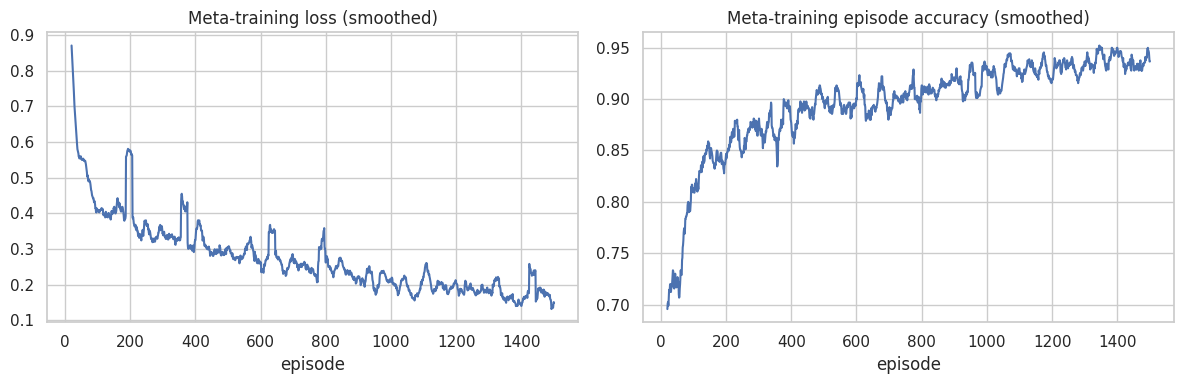

'\nthe loss dropped, taar mane encoder is learning\nand the accuracy increased meaning -> the model classifies unseen query rows well within each mini-task (episode)\n'

In [16]:
N_WAY, K_SHOT_TRAIN, K_QUERY_TRAIN = 3, 5, 15   # 3-way because we only meta-train on 3 seen classes
N_EPISODES = 1500

encoder = Encoder(in_dim=X_train.shape[1])
# this is called adam optimizer with learning rate = 0.001
optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-3)

history = []
"""
build a fresh mini taks via sample_episode
compute loss + accuracy via prototypical_loss
update the encoder wifhts using backpropo + adam


Over 1500 episdoes, the encoder learns an embedding space where
1. same-class examples cluster
2. Dif-class examples separate
3. Distance become meaningful
"""
for ep in range(1, N_EPISODES + 1):
    sup_x, sup_y, qry_x, qry_y = sample_episode(X_train_seen, y_train_seen, SEEN_CLASSES,
                                                 N_WAY, K_SHOT_TRAIN, K_QUERY_TRAIN)
    loss, acc = prototypical_loss(encoder, sup_x, sup_y, qry_x, qry_y, N_WAY)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    history.append((ep, loss.item(), acc))
    if ep % 250 == 0:
        print(f"episode {ep:4d}  loss {loss.item():.3f}  episode-acc {acc:.3f}")

hist_df = pd.DataFrame(history, columns=['episode','loss','acc'])
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(hist_df['episode'], hist_df['loss'].rolling(20).mean()); axes[0].set_title('Meta-training loss (smoothed)')
axes[1].plot(hist_df['episode'], hist_df['acc'].rolling(20).mean());  axes[1].set_title('Meta-training episode accuracy (smoothed)')
for ax in axes: ax.set_xlabel('episode')
plt.tight_layout(); plt.show()

"""
the loss dropped, taar mane encoder is learning
and the accuracy increased meaning -> the model classifies unseen query rows well within each mini-task (episode)
"""


## 4. Few-Shot Learning: classifying the unseen "velocity drift" class


In [21]:
"""
You use meta-learning (Prototypical Networks) to train the encoder, and then you use that trained encoder for few-shot classification.
"""
def few_shot_eval(encoder, X_test, y_test, seen_classes, novel_class, k_shot, seed=0):
    rng = np.random.default_rng(seed)
    all_classes = seen_classes + [novel_class]
    encoder.eval()
    with torch.no_grad():
        used_idx, protos = [], []
        for c in all_classes:
            idx = np.where(y_test == c)[0]
            sel = rng.choice(idx, size=k_shot, replace=False)
            used_idx.extend(sel.tolist())
            z = encoder(torch.tensor(X_test[sel], dtype=torch.float32))
            protos.append(z.mean(0))
        protos = torch.stack(protos)

        query_idx = np.array([i for i in range(len(y_test)) if i not in set(used_idx)])
        z_query = encoder(torch.tensor(X_test[query_idx], dtype=torch.float32))
        pred_pos = torch.cdist(z_query, protos).argmin(1).numpy()
        pred = np.array(all_classes)[pred_pos]
        true = y_test[query_idx]
    return true, pred

for k in [1, 5, 10, 20]:
    true, pred = few_shot_eval(encoder, X_test, y_test, SEEN_CLASSES, NOVEL_CLASS, k_shot=k, seed=1)
    print(f"K={k:2d}-shot  ->  accuracy: {accuracy_score(true,pred):.3f}   "
          f"macro-F1: {f1_score(true,pred,average='macro'):.3f}   "
          f"recall on novel class 3: {f1_score(true==NOVEL_CLASS, pred==NOVEL_CLASS, pos_label=True):.3f}")


K= 1-shot  ->  accuracy: 0.630   macro-F1: 0.574   recall on novel class 3: 0.304
K= 5-shot  ->  accuracy: 0.635   macro-F1: 0.592   recall on novel class 3: 0.486
K=10-shot  ->  accuracy: 0.687   macro-F1: 0.640   recall on novel class 3: 0.443
K=20-shot  ->  accuracy: 0.679   macro-F1: 0.655   recall on novel class 3: 0.515


                   precision    recall  f1-score   support

       Legitimate      0.786     0.704     0.743      2950
Path modification      0.360     0.581     0.444       842
   Ghost aircraft      0.903     0.960     0.931      1058
   Velocity drift      0.564     0.365     0.443       783

         accuracy                          0.687      5633
        macro avg      0.653     0.653     0.640      5633
     weighted avg      0.714     0.687     0.692      5633



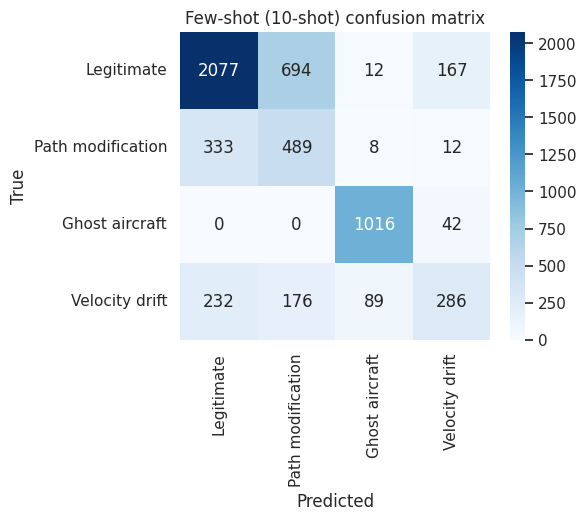

In [22]:
true, pred = few_shot_eval(encoder, X_test, y_test, SEEN_CLASSES, NOVEL_CLASS, k_shot=10, seed=1)
print(classification_report(true, pred, target_names=[label_names[c] for c in [0,1,2,3]], digits=3))

cm = confusion_matrix(true, pred, labels=[0,1,2,3])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_names[c] for c in [0,1,2,3]],
            yticklabels=[label_names[c] for c in [0,1,2,3]], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Few-shot (10-shot) confusion matrix')
plt.show()


## 5. Zero-Shot Learning: classifying the unseen class with **zero** labeled examples


In [23]:
ATTRIBUTES = {
    0: [0, 0, 0, 0, 0],   # legitimate
    1: [1, 0, 0, 0, 1],   # path modification
    2: [1, 1, 1, 1, 0],   # ghost aircraft injection
    3: [0, 1, 0, 0, 1],   # velocity drift  <-- NOVEL, used only as an attribute vector below
}

encoder.eval()
with torch.no_grad():
    z_train = encoder(torch.tensor(X_train, dtype=torch.float32)).numpy()
    z_test  = encoder(torch.tensor(X_test,  dtype=torch.float32)).numpy()

centroids_seen = np.stack([z_train[y_train == c].mean(0) for c in SEEN_CLASSES])
A_seen = np.array([ATTRIBUTES[c] for c in SEEN_CLASSES])

# Linear compatibility model: attribute vector -> embedding centroid
compat_model = Ridge(alpha=1.0).fit(A_seen, centroids_seen)

# Predict the novel class's prototype directly from its attribute vector (ZERO labeled examples)
proto_novel_zeroshot = compat_model.predict(np.array([ATTRIBUTES[NOVEL_CLASS]]))[0]

all_classes = SEEN_CLASSES + [NOVEL_CLASS]
zeroshot_protos = np.vstack([centroids_seen, proto_novel_zeroshot])

dists = np.linalg.norm(z_test[:, None, :] - zeroshot_protos[None, :, :], axis=2)
pred_zeroshot = np.array(all_classes)[dists.argmin(1)]

print(f"Zero-shot accuracy (0 labeled examples of class {NOVEL_CLASS}): {accuracy_score(y_test, pred_zeroshot):.3f}")
print(f"Zero-shot macro-F1: {f1_score(y_test, pred_zeroshot, average='macro'):.3f}")
print(classification_report(y_test, pred_zeroshot, target_names=[label_names[c] for c in [0,1,2,3]], digits=3))


Zero-shot accuracy (0 labeled examples of class 3): 0.648
Zero-shot macro-F1: 0.598
                   precision    recall  f1-score   support

       Legitimate      0.799     0.641     0.711      2960
Path modification      0.365     0.586     0.450       852
   Ghost aircraft      0.879     0.980     0.927      1068
   Velocity drift      0.314     0.294     0.304       793

         accuracy                          0.648      5673
        macro avg      0.589     0.625     0.598      5673
     weighted avg      0.681     0.648     0.655      5673



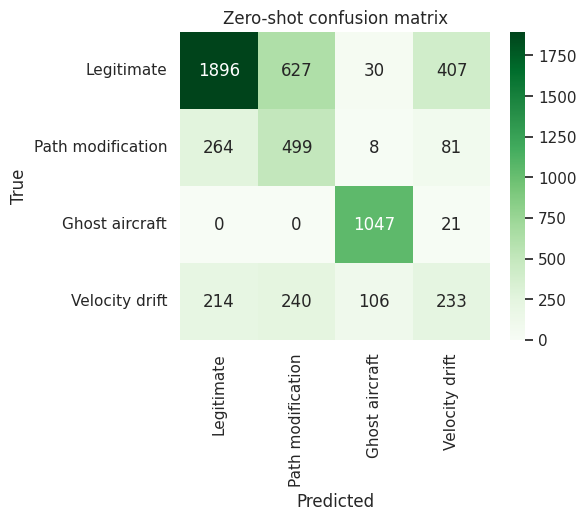

In [24]:
cm = confusion_matrix(y_test, pred_zeroshot, labels=[0,1,2,3])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[label_names[c] for c in [0,1,2,3]],
            yticklabels=[label_names[c] for c in [0,1,2,3]], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Zero-shot confusion matrix')
plt.show()
